Final data shape: (484, 9)


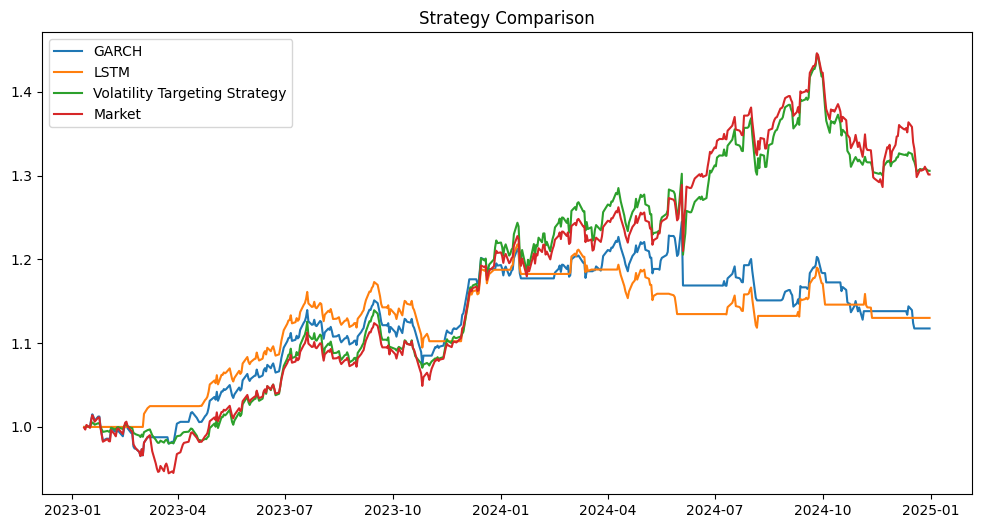

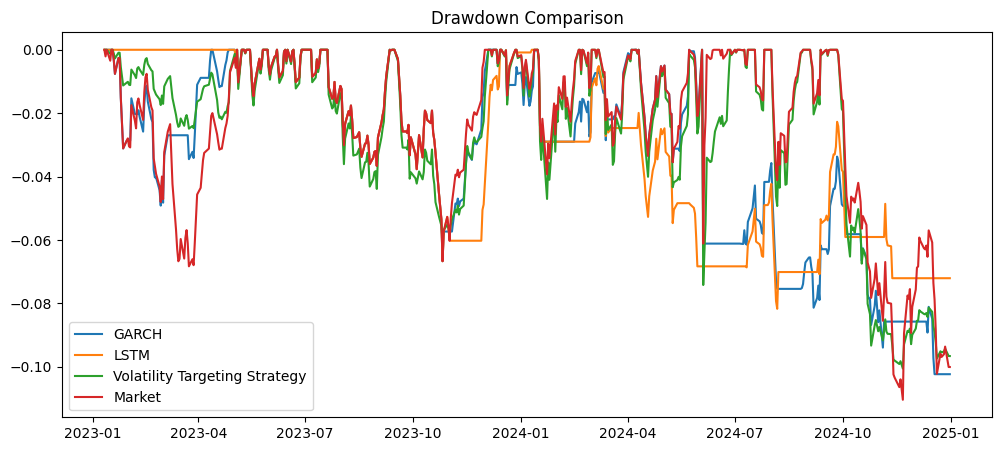

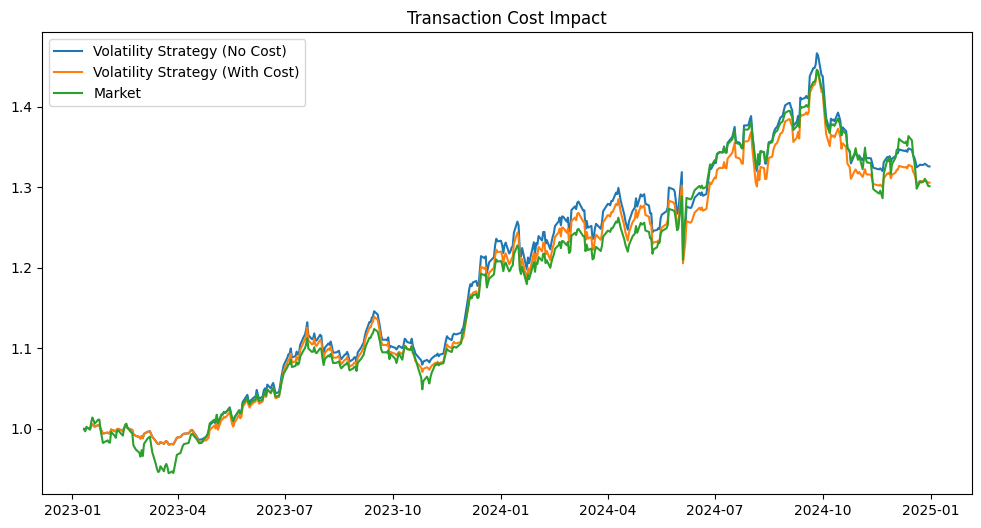


===== FINAL RESULTS =====
GARCH Return: 1.1174991880943406
LSTM Return: 1.1301092270489403
Market Return: 1.301212200522576
Volatility Strategy Return: 1.3056211653196885

SHARPE:
GARCH: 0.6195667492023412
LSTM: 0.8598471774101507
Market: 1.1918461389544157
Volatility Strategy: 1.2424445312924175

Max Drawdown (VT): -0.10054607219715003
Max Drawdown Market: -0.11037939393631473


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==============================
# LOAD DATA
# ==============================

data = load_data("../data/nifty50_processed.csv").dropna()

garch = pd.read_csv("../results/garch_results.csv", index_col=0)
lstm = pd.read_csv("../results/lstm_results.csv", index_col=0)

data.index = pd.to_datetime(data.index)
garch.index = pd.to_datetime(garch.index)
lstm.index = pd.to_datetime(lstm.index)

data = data.sort_index()
garch = garch.sort_index()
lstm = lstm.sort_index()

data = data.join(garch[['garch_vol']], how='inner')
data = data.join(lstm[['lstm_pred']], how='inner')

data = data.dropna()

print("Final data shape:", data.shape)


# ==============================
# HELPER FUNCTIONS
# ==============================

def sharpe_ratio(returns):
    returns = returns.dropna()
    if returns.std() == 0:
        return 0
    return np.mean(returns) / np.std(returns) * np.sqrt(252)

def drawdown(series):
    peak = series.cummax()
    return (series - peak) / peak


# ==============================
# GARCH STRATEGY
# ==============================

threshold = data['garch_vol'].quantile(0.7)

data['garch_position'] = np.where(data['garch_vol'] < threshold, 1, 0)
data['garch_strategy'] = data['garch_position'].shift(1) * data['returns']


# ==============================
# LSTM STRATEGY
# ==============================

threshold = data['lstm_pred'].median()

data['lstm_position'] = np.where(data['lstm_pred'] < threshold, 1, 0)
data['lstm_strategy'] = data['lstm_position'].shift(1) * data['returns']

data[['garch_strategy', 'lstm_strategy']] = data[['garch_strategy', 'lstm_strategy']].fillna(0)


# ==============================
# VOLATILITY TARGETING STRATEGY
# ==============================

target_vol = 0.15

data['daily_vol'] = data['garch_vol'] / np.sqrt(252)
data['daily_vol'] = data['daily_vol'].replace(0, np.nan).bfill()

data['vt_position'] = (target_vol / data['daily_vol']) ** 1.5
data['vt_position'] = data['vt_position'].clip(0, 1.2)
data['vt_position'] = data['vt_position'].ewm(span=5).mean()

# Trend filter
data['trend'] = data['returns'].rolling(50).mean()

data['vt_position'] = np.where(
    data['trend'] > 0,
    data['vt_position'],
    data['vt_position'] * 0.3
)

# Strategy returns
data['vt_strategy'] = data['vt_position'].shift(1) * data['returns']
data['vt_strategy'] = data['vt_strategy'].fillna(0)

# Transaction cost
cost = 0.001   
data['turnover'] = data['vt_position'].diff().abs()
data['cost'] = data['turnover'] * cost

data['vt_strategy_net'] = data['vt_strategy'] - data['cost']


# ==============================
# CUMULATIVE RETURNS
# ==============================

data['buy_hold'] = data['returns'].fillna(0)

data['cum_garch'] = (1 + data['garch_strategy']).cumprod()
data['cum_lstm'] = (1 + data['lstm_strategy']).cumprod()
data['cum_vt'] = (1 + data['vt_strategy_net']).cumprod()
data['cum_vt_nocost'] = (1 + data['vt_strategy']).cumprod()
data['cum_market'] = (1 + data['buy_hold']).cumprod()


# ==============================
# DRAWDOWN CONTROL (IMPORTANT)
# ==============================

temp_cum = (1 + data['vt_strategy_net']).cumprod()
rolling_max = temp_cum.cummax()
dd = (temp_cum - rolling_max) / rolling_max

# Reduce exposure if drawdown exceeds 10%
data['vt_position'] = np.where(dd < -0.08, data['vt_position'] * 0.3, data['vt_position'])

# Recalculate returns after adjustment
data['vt_strategy'] = data['vt_position'].shift(1) * data['returns']
data['vt_strategy'] = data['vt_strategy'].fillna(0)

data['vt_strategy_net'] = data['vt_strategy'] - data['cost']



# ==============================
# STRATEGY COMPARISON PLOT
# ==============================

plt.figure(figsize=(12,6))
plt.plot(data['cum_garch'], label='GARCH')
plt.plot(data['cum_lstm'], label='LSTM')
plt.plot(data['cum_vt'], label='Volatility Targeting Strategy')
plt.plot(data['cum_market'], label='Market')
plt.legend()
plt.title("Strategy Comparison")
plt.show()


# ==============================
# DRAWDOWN
# ==============================

data['dd_garch'] = drawdown(data['cum_garch'])
data['dd_lstm'] = drawdown(data['cum_lstm'])
data['dd_vt'] = drawdown(data['cum_vt'])
data['dd_market'] = drawdown(data['cum_market'])

plt.figure(figsize=(12,5))
plt.plot(data['dd_garch'], label='GARCH')
plt.plot(data['dd_lstm'], label='LSTM')
plt.plot(data['dd_vt'], label='Volatility Targeting Strategy')
plt.plot(data['dd_market'], label='Market')
plt.legend()
plt.title("Drawdown Comparison")
plt.show()


# ==============================
# TRANSACTION COST IMPACT
# ==============================

plt.figure(figsize=(12,6))
plt.plot(data['cum_vt_nocost'], label='Volatility Strategy (No Cost)')
plt.plot(data['cum_vt'], label='Volatility Strategy (With Cost)')
plt.plot(data['cum_market'], label='Market')
plt.legend()
plt.title("Transaction Cost Impact")
plt.show()


# ==============================
# FINAL METRICS
# ==============================

print("\n===== FINAL RESULTS =====")

print("GARCH Return:", data['cum_garch'].iloc[-1])
print("LSTM Return:", data['cum_lstm'].iloc[-1])
print("Market Return:", data['cum_market'].iloc[-1])
print("Volatility Strategy Return:", data['cum_vt'].iloc[-1])

print("\nSHARPE:")
print("GARCH:", sharpe_ratio(data['garch_strategy']))
print("LSTM:", sharpe_ratio(data['lstm_strategy']))
print("Market:", sharpe_ratio(data['buy_hold']))
print("Volatility Strategy:", sharpe_ratio(data['vt_strategy_net']))

print("\nMax Drawdown (VT):", data['dd_vt'].min())
print("Max Drawdown Market:", data['dd_market'].min())


In [2]:
data.to_csv("../results/full_backtest_data.csv")